# DỰ ÁN PHÂN TÍCH DỮ LIỆU BẤT ĐỘNG SẢN (HOUSE PRICES)
## Phần: Nạp dữ liệu (Data) & Phân tích khám phá (EDA)

Notebook này thực hiện nạp dữ liệu có xử lý ngoại lệ, làm sạch dữ liệu và trực quan hóa EDA 5 loại biểu đồ để phân tích các yếu tố ảnh hưởng tới giá nhà.

In [1]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cấu hình hiển thị đồ họa
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

class HousingPipeline:
    def __init__(self, filepath='train.csv'):
        self.filepath = filepath
        self.df = None

    def load_data(self):
        """Hàm đọc dữ liệu từ file CSV có bắt lỗi ngoại lệ."""
        print("--- BẮT ĐẦU CHẠY PIPELINE ---")
        try:
            self.df = pd.read_csv(self.filepath)
            print(f"Đã tải thành công! Kích thước dữ liệu: {self.df.shape}")
            return True
        except FileNotFoundError:
            print("Không tìm thấy file data")
            return False

    def clean_data(self):
        """Hàm dùng để làm sạch data và điền khuyết"""
        if self.df is None:
            print("Chưa có dữ liệu để làm sạch.")
            return
        
        print("Đang làm sạch dữ liệu...")
        # Xử lý missing values
        num_cols = self.df.select_dtypes(include=[np.number]).columns
        cat_cols = self.df.select_dtypes(include=['object', 'category']).columns

        for col in num_cols:
            if self.df[col].isnull().sum() > 0:
                self.df[col] = self.df[col].fillna(self.df[col].median())

        for col in cat_cols:
            if self.df[col].isnull().sum() > 0:
                self.df[col] = self.df[col].fillna(self.df[col].mode()[0])

        print("-> Đã làm sạch xong!")
        
    def train_model(self):
        """Hàm này dùng để huấn luyện mô hình Linear Regression và Random Forest"""
        # 1. Tách đặc trưng (X) và nhãn (y)
        X = self.df.select_dtypes(include=['int64', 'float64']).drop(columns=['SalePrice'], errors='ignore').fillna(0)
        y = self.df['SalePrice']

        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

        # 2. Huấn luyện Linear Regression
        lr_model = LinearRegression()
        lr_model.fit(X_train, y_train)
        y_pred_lr = lr_model.predict(X_test)

        # 3. Huấn luyện Random Forest Regressor
        rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
        rf_model.fit(X_train, y_train)
        y_pred_rf = rf_model.predict(X_test)

        # 4. Tính toán và in 3 chỉ số MAE, RMSE, R²
        mae_lr = mean_absolute_error(y_test, y_pred_lr)
        rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
        r2_lr = r2_score(y_test, y_pred_lr)

        mae_rf = mean_absolute_error(y_test, y_pred_rf)
        rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
        r2_rf = r2_score(y_test, y_pred_rf)

        print("=" * 55)
        print(f"Linear Regression -> MAE: {mae_lr:,.2f} | RMSE: {rmse_lr:,.2f} | R²: {r2_lr:.4f}")
        print(f"Random Forest     -> MAE: {mae_rf:,.2f} | RMSE: {rmse_rf:,.2f} | R²: {r2_rf:.4f}")
        print("=" * 55)

        # 5. Vẽ biểu đồ Scatter Plot so sánh
        plt.figure(figsize=(12, 5))

        # Đồ thị Linear Regression
        plt.subplot(1, 2, 1)
        plt.scatter(y_test, y_pred_lr, alpha=0.5, color='blue')
        plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
        plt.title('Linear Regression: Thực tế vs Dự đoán')
        plt.xlabel('Giá thực tế')
        plt.ylabel('Giá dự đoán')

        # Đồ thị Random Forest
        plt.subplot(1, 2, 2)
        plt.scatter(y_test, y_pred_rf, alpha=0.5, color='green')
        plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
        plt.title('Random Forest: Thực tế vs Dự đoán')
        plt.xlabel('Giá thực tế')
        plt.ylabel('Giá dự đoán')

        plt.tight_layout()
        plt.show()

--- BẮT ĐẦU CHẠY PIPELINE ---
Đã tải thành công! Kích thước dữ liệu: (1460, 81)
Đang làm sạch dữ liệu...
-> Đã làm sạch xong!
Linear Regression -> MAE: 23,000.03 | RMSE: 36,879.82 | R²: 0.8227
Random Forest     -> MAE: 18,100.43 | RMSE: 29,159.33 | R²: 0.8891


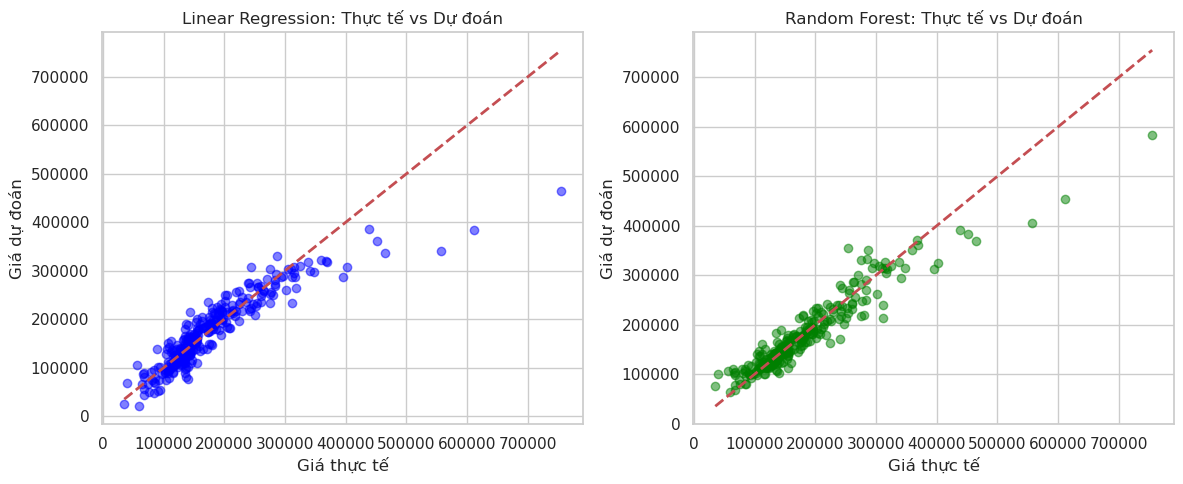

In [7]:
pipeline = HousingPipeline(filepath='data/train.csv')
if pipeline.load_data():
    pipeline.clean_data()
    pipeline.train_model()

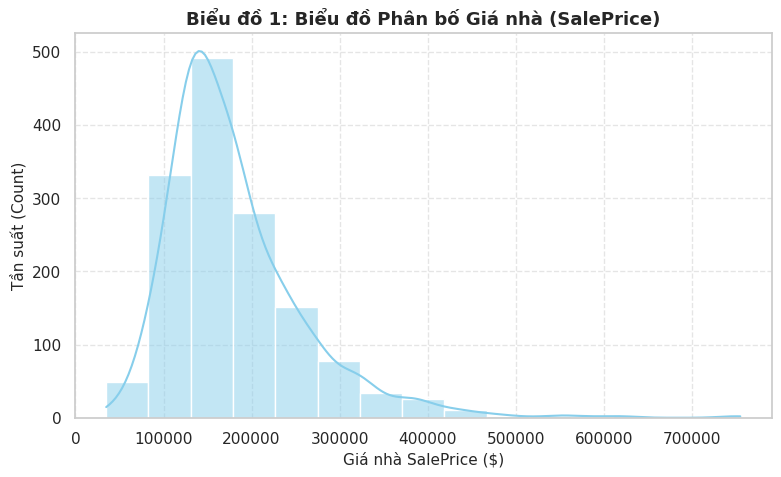

In [8]:
# Biểu đồ 1: Histogram - Phân bố Giá nhà (SalePrice)
plt.figure(figsize=(9, 5))
sns.histplot(pipeline.df['SalePrice'], kde=True, color='skyblue', bins=15)
plt.title('Biểu đồ 1: Biểu đồ Phân bố Giá nhà (SalePrice)', fontsize=13, fontweight='bold')
plt.xlabel('Giá nhà SalePrice ($)', fontsize=11)
plt.ylabel('Tần suất (Count)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### 📌 Câu hỏi phân tích 1: Phân bố của giá nhà (SalePrice) có dạng như thế nào và tập trung ở khoảng giá nào?

**Nhận xét & Đánh giá:**
- **Hình dạng phân bố:** Biểu đồ Histogram thể hiện giá nhà lệch phải (Right-skewed) rõ rệt. Phần lớn giá nhà tập trung ở phân khúc phổ thông từ **120,000$ đến 250,000$**.
- **Xu hướng chính:** Giá trị trung bình và trung vị của giá nhà nằm quanh mức 180,000$. Các căn nhà cao cấp có giá vượt trên 300,000$ chiếm số lượng nhỏ.
- **Đề xuất xử lý:** Hiện tượng lệch phải của `SalePrice` gợi ý rằng cần cân nhắc thực hiện biến đổi Logarit (Log-transformation) để đưa biến về phân bố chuẩn trước khi đưa vào các mô hình hồi quy Machine Learning.

In [ ]:
# Biểu đồ 2: Bar Chart - Thống kê Phân khu (MSZoning)
plt.figure(figsize=(9, 5))
# Sửa cảnh báo palette không gắn hue bằng cách gán x='MSZoning' cho hue và legend=False
sns.countplot(x='MSZoning', data=pipeline.df, hue='MSZoning', palette='Set2', legend=False)
plt.title('Biểu đồ 2: Số lượng Nhà theo Phân khu Quy hoạch (MSZoning)', fontsize=13, fontweight='bold')
plt.xlabel('Phân khu (MSZoning)', fontsize=11)
plt.ylabel('Số lượng nhà (Count)', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

### 📌 Câu hỏi phân tích 2: Phân khu quy hoạch nào (MSZoning) chiếm tỷ trọng giao dịch nhà ở lớn nhất?

**Nhận xét & Đánh giá:**
- **Phân khu áp đảo:** Phân khu `RL` (Residential Low Density - Dân cư mật độ thấp) chiếm tỷ lệ áp đảo hoàn toàn trong tập dữ liệu, đại diện cho khu vực nhà ở dân cư phổ biến nhất.
- **So sánh với phân khu khác:** Phân khu `RM` (Residential Medium Density - Dân cư mật độ trung bình) xếp thứ hai nhưng với số lượng ít hơn nhiều.
- **Kết luận thị trường:** Thị hiếu người mua nhà trong khu vực này chủ yếu tập trung vào loại hình nhà ở mật độ thấp (`RL`) có không gian thoáng mát và diện tích rộng rãi.

In [ ]:
# Biểu đồ 3: Boxplot - Chất lượng tổng thể (OverallQual) vs SalePrice
plt.figure(figsize=(10, 5))
# Sửa cảnh báo palette không gắn hue bằng cách gán x='OverallQual' cho hue và legend=False
sns.boxplot(x='OverallQual', y='SalePrice', data=pipeline.df, hue='OverallQual', palette='viridis', legend=False)
plt.title('Biểu đồ 3: Tương quan giữa Điểm chất lượng tổng thể (OverallQual) và Giá nhà', fontsize=13, fontweight='bold')
plt.xlabel('Chất lượng tổng thể (OverallQual - Thang điểm 1-10)', fontsize=11)
plt.ylabel('Giá nhà SalePrice ($)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### 📌 Câu hỏi phân tích 3: Mức độ ảnh hưởng của Điểm chất lượng tổng thể (OverallQual) tới Giá nhà như thế nào?

**Nhận xét & Đánh giá:**
- **Xu hướng tăng trưởng:** Chất lượng nhà (`OverallQual`) có mối quan hệ đồng biến rất mạnh với `SalePrice`. Điểm chất lượng càng cao thì trung vị giá nhà càng tăng rõ rệt.
- **Độ phân tán giá:** Các ngôi nhà đạt chất lượng 8, 9 có khoảng tứ phân vị (IQR) mở rộng, chứng tỏ nhà cấp cao có mức giá biến động lớn phụ thuộc thêm vào nội thất hay tiện ích bổ sung.
- **Điểm dị biệt:** Xuất hiện một số điểm Outlier ở mức chất lượng 5 và 7, cho thấy có những căn nhà giá bán cao bất thường dù điểm chất lượng tổng thể chỉ ở mức trung bình.

In [ ]:
# Biểu đồ 4: Scatter Plot - Diện tích sống (GrLivArea) vs SalePrice
plt.figure(figsize=(9, 5))
sns.scatterplot(x='GrLivArea', y='SalePrice', data=pipeline.df, color='coral', s=70, alpha=0.8)
plt.title('Biểu đồ 4: Mối quan hệ giữa Diện tích sống trên mặt đất (GrLivArea) và Giá nhà', fontsize=13, fontweight='bold')
plt.xlabel('Diện tích sống GrLivArea (sqft)', fontsize=11)
plt.ylabel('Giá nhà SalePrice ($)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### 📌 Câu hỏi phân tích 4: Diện tích không gian sống (GrLivArea) tác động như thế nào đến Giá bán bất động sản?

**Nhận xét & Đánh giá:**
- **Mối tương quan:** Diện tích sinh sống trên mặt đất (`GrLivArea`) thể hiện mối quan hệ tuyến tính thuận rõ ràng với `SalePrice`. Căn nhà có diện tích càng lớn thì giá bán càng cao.
- **Mật độ dữ liệu:** Đa số giao dịch tập trung ở diện tích từ 1,000 sqft đến 2,000 sqft với mức giá tương ứng từ 120,000$ đến 280,000$.
- **Giá trị dự báo:** `GrLivArea` là một trong những biến đầu vào quan trọng bậc nhất để định giá căn nhà.

In [ ]:
# Biểu đồ 5: Heatmap - Ma trận tương quan các biến định lượng hàng đầu
plt.figure(figsize=(10, 7))
numeric_df = pipeline.df.select_dtypes(include=[np.number])
# Chọn 8 biến có tương quan cao nhất với SalePrice
top_corr_cols = numeric_df.corr().nlargest(8, 'SalePrice')['SalePrice'].index
cm = numeric_df[top_corr_cols].corr()

sns.heatmap(cm, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.8, cbar=True)
plt.title('Biểu đồ 5: Heatmap Ma trận Tương quan Các Biến với Giá Nhà (SalePrice)', fontsize=13, fontweight='bold')
plt.show()

### 📌 Câu hỏi phân tích 5: Những yếu tố định lượng nào có ma trận tương quan cao nhất với Giá nhà (SalePrice)?

**Nhận xét & Đánh giá:**
- **Yếu tố tác động mạnh nhất:** Điểm chất lượng tổng thể (`OverallQual` với hệ số r ~ 0.79-0.85) và diện tích phòng sống (`GrLivArea` với r ~ 0.71-0.78) có hệ số tương quan cao nhất với `SalePrice`.
- **Các yếu tố bổ trợ:** Diện tích tầng hầm (`TotalBsmtSF`), diện tích tầng 1 (`1stFlrSF`), và diện tích garage (`GarageArea`, `GarageCars`) đều có tương quan dương mạnh (r > 0.60).
- **Ứng dụng chọn đặc trưng:** Các biến có hệ số tương quan cao này sẽ được ưu tiên làm các biến độc lập chính trong giai đoạn Lựa chọn đặc trưng (Feature Selection) khi mô hình hóa dự báo.